# Redes neuronales para la clasificación de emociones

Curso: Minería de Datos

Proyecto: Clasificación automática de emociones en publicaciones de jóvenes peruanos

### 1. Preparación del entorno

#### Verificar la GPU

Utilizaremos Google Colab para aprovechar su GPU y que el proceso sea mucho más rápido.

In [11]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo detectado: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("[!] NO se detectó GPU. El entrenamiento será muy lento.")

Dispositivo detectado: cuda
GPU: Tesla T4
Memoria: 15.6 GB


#### Entorno de ejecución

In [1]:
import os
import sys

# Detección del entorno de ejecución
if os.path.exists('/content'):
    print("Entorno Nube (Colab) Detectado.")
    print("Montando Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print("Error al montar Drive:", e)
    
    BASE_DIR = '/content'
    DATOS_DIR = '/content/drive/MyDrive/Proyecto-Mineria-G4/prueba'
else:
    print("Entorno Local Detectado.")
    try:
        current_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        current_dir = os.getcwd()

    BASE_DIR = current_dir
    while BASE_DIR != os.path.dirname(BASE_DIR):
        if 'modelado' in os.listdir(BASE_DIR) and os.path.isdir(os.path.join(BASE_DIR, 'modelado')):
            break
        BASE_DIR = os.path.dirname(BASE_DIR)
        
    DATOS_DIR = os.path.join(BASE_DIR, 'modelado', 'datos')

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

RESULTADOS_DIR = os.path.join(BASE_DIR, 'resultados_nn' if '/content' in BASE_DIR else 'modelado/resultados_nn')
os.makedirs(RESULTADOS_DIR, exist_ok=True)

print(f"Directorio de datos: {DATOS_DIR}")
print(f"Directorio de resultados: {RESULTADOS_DIR}")


Entorno Nube (Colab) Detectado.
Montando Google Drive...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de datos: /content/drive/MyDrive/Proyecto-Mineria-G4/prueba
Directorio de resultados: /content/resultados_nn


#### Importación de librerías

In [2]:
import glob
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de procesamiento detectado: {device}")

Dispositivo de procesamiento detectado: cuda


#### Hiperparámetros de la Red Neuronal


In [3]:
# Valores
MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 64
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 3 # Early stopping tolerance
LEARNING_RATE = 0.001

### 2. Carga y estandarización de los datasets

Se cargan los 3 datasets preprocesados (YouTube parte 1, YouTube parte 2, TikTok) y se unifican en un solo dataframe.

In [4]:
archivos = [
    os.path.join(DATOS_DIR, 'dataset_procesado_tiktok_parte01.csv'),
    os.path.join(DATOS_DIR, 'dataset_procesado_youtube_parte01.csv'),
    os.path.join(DATOS_DIR, 'dataset_procesado_youtube_parte02.csv')
]

dfs = []
for f in archivos:
    if os.path.exists(f):
        print(f"Cargando {os.path.basename(f)}...")
        temp_df = pd.read_csv(f, sep=';', encoding='utf-8')
        temp_df.columns = temp_df.columns.str.strip().str.replace('"', '').str.lower()
        dfs.append(temp_df)

if not dfs:
    raise ValueError(f"No se encontraron datasets en la ruta: {DATOS_DIR}")

df = pd.concat(dfs, ignore_index=True)
df['emocion'] = df['emocion'].astype(str).str.strip().str.replace('"', '').str.capitalize()
df['emocion'] = df['emocion'].replace({'Alegría': 'Alegria'})

# Filtro de las emociones
emociones_validas = ['Sorpresa', 'Miedo', 'Alegria', 'Tristeza']
df = df[df['emocion'].isin(emociones_validas)]
df = df.dropna(subset=['lemas', 'emocion'])

print(f"\nTotal de registros consolidados: {len(df)}")
print(f"Distribución de clases:\n{df['emocion'].value_counts()}")


Cargando dataset_procesado_tiktok_parte01.csv...
Cargando dataset_procesado_youtube_parte01.csv...
Cargando dataset_procesado_youtube_parte02.csv...

Total de registros consolidados: 9065
Distribución de clases:
emocion
Tristeza    2684
Alegria     2329
Sorpresa    2048
Miedo       2004
Name: count, dtype: int64


### 3. Preparación de tensores


In [5]:
le = LabelEncoder()
y = le.fit_transform(df['emocion'])
# La columna 'lemas' evita stopwords y normaliza palabras
texts = df['lemas'].astype(str).tolist()

def build_vocab(texts, max_words=MAX_WORDS):
    words = []
    for text in texts:
        words.extend(str(text).split())
    counter = collections.Counter(words)
    # 0 = padding, 1 = unk
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(counter.most_common(max_words - 2))}
    return vocab

def texts_to_sequences(texts, vocab):
    seqs = []
    for text in texts:
        seq = [vocab.get(w, 1) for w in str(text).split()]
        seqs.append(seq)
    return seqs

def pad_sequences(seqs, maxlen=MAX_LEN):
    padded = np.zeros((len(seqs), maxlen), dtype=int)
    for i, seq in enumerate(seqs):
        if len(seq) > maxlen:
            padded[i, :] = seq[:maxlen]
        else:
            padded[i, -len(seq):] = seq
    return padded

vocab = build_vocab(texts)
vocab_size = min(MAX_WORDS, len(vocab) + 2)
seqs = texts_to_sequences(texts, vocab)
X = pad_sequences(seqs)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(le.classes_)
print(f"Clases identificadas ({num_classes}): {le.classes_}")
print(f"Conjunto de Entrenamiento: {len(X_train)} muestras")
print(f"Conjunto de Prueba: {len(X_test)} muestras")


Clases identificadas (4): ['Alegria' 'Miedo' 'Sorpresa' 'Tristeza']
Conjunto de Entrenamiento: 6345 muestras
Conjunto de Prueba: 2720 muestras


### 4. Definición de modelos de deep learning (CNN y LSTM)


In [6]:
# CNN 1D
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x) 
        x = x.permute(0, 2, 1) 
        x = self.conv(x)
        x = self.relu(x)
        x = torch.max(x, dim=2)[0] 
        out = self.fc(x)
        return out

# LSTM
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, (hn, cn) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

print("Modelos listos.")

Modelos listos.


#### Función de entrenamiento de los modelos


In [7]:
def train_model(model, train_loader, val_loader, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        print(f"   Época {epoch+1}/{EPOCHS} - Perdida Train: {train_loss:.4f} - Perdida Val: {val_loss:.4f}")
        
        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("   [!] Early stopping ejecutado.")
                break
    return model

print("Función generica de entrenamiento de los modelos listo.")

Función generica de entrenamiento de los modelos listo.


#### Función de evaluación de los modelos con las métricas

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_and_plot(model, nombre_modelo, dataloader, device, le, archivo_reporte):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) # Sensibilidad
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    print(f"\n Resultados para {nombre_modelo}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Sensibilidad/Recall (macro): {rec:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")
            
    print(f"\nReporte de Clasificación:")
    y_test_labels = le.inverse_transform(all_labels)
    y_pred_labels = le.inverse_transform(all_preds)
    reporte_str = classification_report(y_test_labels, y_pred_labels, labels=le.classes_, zero_division=0)
    print(reporte_str)
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    ruta_cm = os.path.join(RESULTADOS_DIR, f'cm_{nombre_modelo}.png')
    plt.savefig(ruta_cm)
    plt.show()
    
    # 2. Curva ROC / AUC (One-vs-Rest)
    y_test_bin = label_binarize(all_labels, classes=range(len(le.classes_)))
    n_classes = len(le.classes_)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    plt.figure(figsize=(7, 6))
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC (area = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)
             
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
    for i, color in zip(range(n_classes), colors):
        c = color if i < len(colors) else 'black'
        plt.plot(fpr[i], tpr[i], color=c, lw=2,
                 label=f'ROC {le.classes_[i]} (area = {roc_auc[i]:.2f})')
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.title(f'Curva ROC Multiclase (OvR) - {nombre_modelo}')
    plt.legend(loc="lower right", fontsize=8)
    ruta_roc = os.path.join(RESULTADOS_DIR, f'roc_{nombre_modelo}.png')
    plt.savefig(ruta_roc)
    plt.show()
    
    # Escribir resultados en el archivo markdown
    with open(archivo_reporte, 'a', encoding='utf-8') as f:
        f.write(f"## {nombre_modelo}\n\n")
        f.write(f"- **Accuracy:** {acc:.4f}\n")
        f.write(f"- **Precision (macro):** {prec:.4f}\n")
        f.write(f"- **Sensibilidad/Recall (macro):** {rec:.4f}\n")
        f.write(f"- **F1-Score (macro):** {f1:.4f}\n\n")
        
        f.write("```text\n")
        f.write(reporte_str)
        f.write("\n```\n\n")
        
        f.write(f"**Matriz de Confusión:**\n\n![Matriz de Confusión {nombre_modelo}](./cm_{nombre_modelo}.png)\n\n")
        
        f.write(f"**Curva ROC / AUC:**\n\n![Curva ROC {nombre_modelo}](./roc_{nombre_modelo}.png)\n\n")

print("Función generica de evaluación de los modelos y exportación de los resultados listo.")

Función generica de evaluación de los modelos y exportación de los resultados listo.


### 5. Ejecución del pipeline

Entrenando modelo CNN

   Época 1/10 - Perdida Train: 1.1805 - Perdida Val: 1.0866
   Época 2/10 - Perdida Train: 0.8886 - Perdida Val: 1.0333
   Época 3/10 - Perdida Train: 0.6709 - Perdida Val: 1.0152
   Época 4/10 - Perdida Train: 0.4647 - Perdida Val: 1.0547
   Época 5/10 - Perdida Train: 0.2894 - Perdida Val: 1.1225
   Época 6/10 - Perdida Train: 0.1812 - Perdida Val: 1.1572
   [!] Early stopping ejecutado.

Evaluando modelo CNN...

 Resultados para CNN
Accuracy: 0.5824
Precision (macro): 0.5864
Sensibilidad/Recall (macro): 0.5825
F1-Score (macro): 0.5822

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.59      0.47      0.52       699
       Miedo       0.72      0.72      0.72       601
    Sorpresa       0.48      0.50      0.49       615
    Tristeza       0.56      0.64      0.60       805

    accuracy                           0.58      2720
   macro avg       0.59      0.58      0.58      2720
weighted avg       0.58   

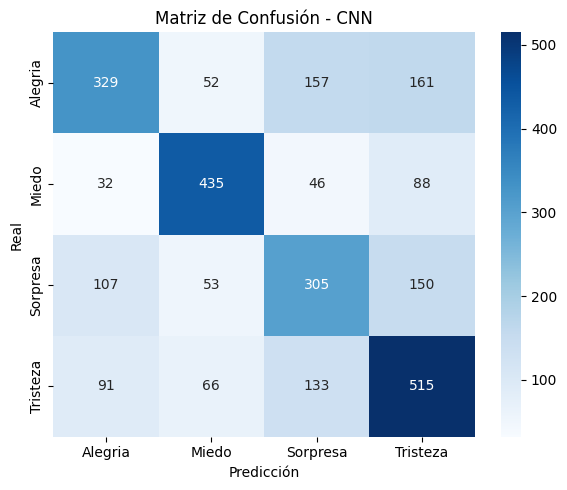

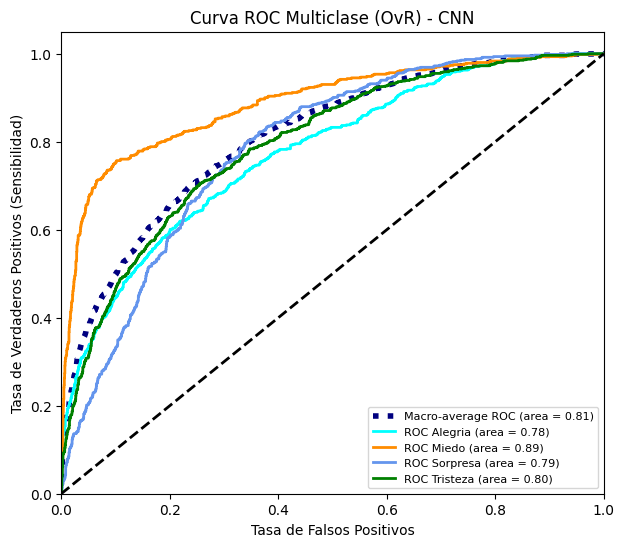

Entrenando modelo LSTM

   Época 1/10 - Perdida Train: 1.3071 - Perdida Val: 1.1811
   Época 2/10 - Perdida Train: 1.0669 - Perdida Val: 1.1045
   Época 3/10 - Perdida Train: 0.9541 - Perdida Val: 1.1288
   Época 4/10 - Perdida Train: 0.8605 - Perdida Val: 1.0796
   Época 5/10 - Perdida Train: 0.7514 - Perdida Val: 1.0961
   Época 6/10 - Perdida Train: 0.7019 - Perdida Val: 1.1660
   Época 7/10 - Perdida Train: 0.5750 - Perdida Val: 1.1972
   [!] Early stopping ejecutado.

Evaluando modelo LSTM...

 Resultados para LSTM
Accuracy: 0.5563
Precision (macro): 0.5665
Sensibilidad/Recall (macro): 0.5592
F1-Score (macro): 0.5612

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.53      0.47      0.50       699
       Miedo       0.74      0.67      0.70       601
    Sorpresa       0.45      0.53      0.49       615
    Tristeza       0.55      0.57      0.56       805

    accuracy                           0.56      2720
   macro avg     

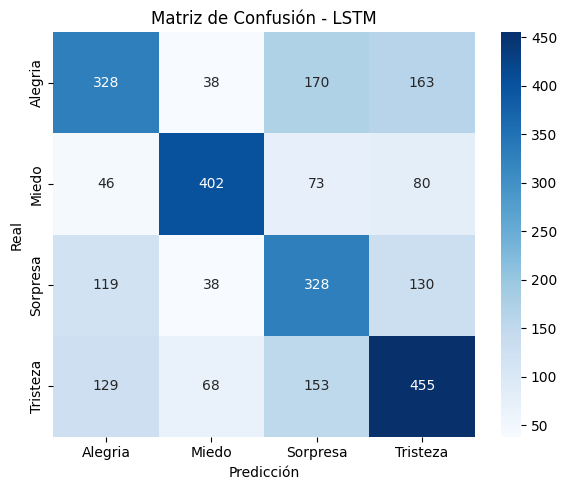

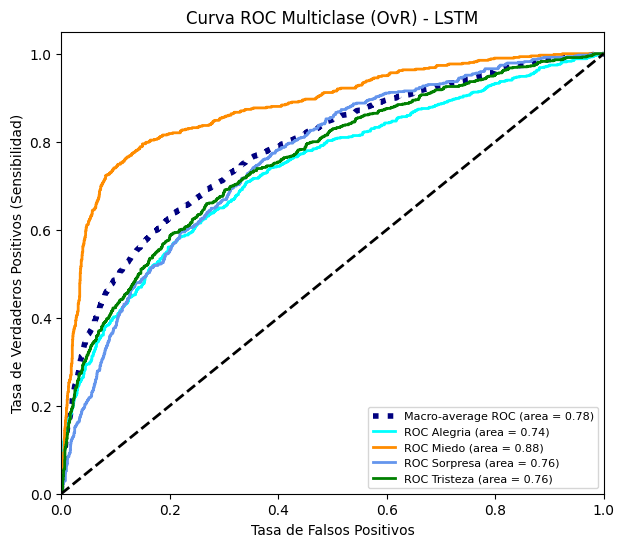


Proceso completado. Reporte guardado en: /content/resultados_nn/reporte_redes_neuronales.md


In [10]:
archivo_reporte = os.path.join(RESULTADOS_DIR, 'reporte_redes_neuronales.md')
with open(archivo_reporte, 'w', encoding='utf-8') as f:
    f.write("# Reporte de evaluación de redes neuronales profundas\n\n")
    f.write("Resultados de las métricas de rendimiento para los modelos CNN y LSTM.\n\n")

modelos = {
    'CNN': CNNModel(vocab_size, EMBEDDING_DIM, num_classes).to(device),
    'LSTM': LSTMModel(vocab_size, EMBEDDING_DIM, num_classes).to(device)
}

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo {nombre}\n")
    modelo = train_model(modelo, train_loader, test_loader, device)
    
    print(f"\nEvaluando modelo {nombre}...")
    evaluate_and_plot(modelo, nombre, test_loader, device, le, archivo_reporte)

print(f"\nProceso completado. Reporte guardado en: {archivo_reporte}")
